# Final Calibrated Simulation - Based on Real Data Analysis

## Calibration from Actual Data:

### Price Sensitivity (Conversion Rate Change):
- **Pharma**: 84-86% (FLAT) → Elasticity: -0.05 (nearly inelastic)
- **Meal**: 55% → 49% (-6pts) → Elasticity: -0.20 (modest)
- **Grocery**: 43% → 35% (-8pts) → Elasticity: -0.30 (moderate)

### KEY INSIGHT:
**Higher prices REDUCE blocking** (5.3% → 3.3%) **AND increase revenue**

This is the **IDEAL scenario** for dynamic pricing! 🎯

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

print("✓ Setup complete")

✓ Setup complete


In [2]:
# UPDATE THESE PATHS
SESSION_FILE = '../data/raw/zipline_session_log_(5).csv'

session_df = pd.read_csv(SESSION_FILE)
session_df['timestamp'] = pd.to_datetime(session_df['timestamp'])
session_df['delivery_fee'] = pd.to_numeric(session_df['delivery_fee'], errors='coerce')
session_df['subtotal'] = pd.to_numeric(session_df['subtotal'], errors='coerce')
session_df['distance_miles'] = pd.to_numeric(session_df['distance_miles'], errors='coerce')
session_df['subtotal'] = session_df['subtotal'].fillna(session_df['subtotal'].median())

print(f"✓ Loaded {len(session_df):,} sessions")
print(f"✓ Date range: {session_df['timestamp'].min().date()} to {session_df['timestamp'].max().date()}")

✓ Loaded 59,880 sessions
✓ Date range: 2024-01-01 to 2024-01-13


In [3]:
from dynamic_pricing_model_v3 import ZiplineDynamicPricingFinal

model = ZiplineDynamicPricingFinal()

print("✓ Final calibrated model loaded")
print("\nBase Prices:")
for order_type, price in model.base_prices.items():
    print(f"  {order_type}: ${price:.2f}")

print("\nExample Surge Pricing (Meal, 7 miles):")
for util in [0.3, 0.5, 0.7, 0.85, 0.95]:
    price = model.calculate_price(5, 'Meal', 7.0, util)
    print(f"  {util*100:>3.0f}% capacity → ${price:.2f}")

✓ Final calibrated model loaded

Base Prices:
  Grocery: $5.49
  Meal: $5.99
  Pharma: $8.99

Example Surge Pricing (Meal, 7 miles):
   30% capacity → $5.99
   50% capacity → $6.99
   70% capacity → $7.99
   85% capacity → $9.99
   95% capacity → $11.99


## Final Calibrated Simulator

In [4]:
class FinalSimulator:
    """
    Final simulator with calibrated elasticity from real data.
    """
    
    def __init__(self, session_df, model):
        self.session_df = session_df.copy()
        self.model = model
        self.base_stats = self._calculate_base_stats()
        
    def _calculate_base_stats(self):
        stats = {}
        for order_type in ['Grocery', 'Meal', 'Pharma']:
            type_data = self.session_df[self.session_df['order_type'] == order_type]
            stats[order_type] = {
                'base_conversion': (type_data['session_outcome'] == 'ordered').mean(),
                'base_blocking': (type_data['session_outcome'] == 'blocked').mean(),
                'base_price': type_data['delivery_fee'].median()
            }
        return stats
    
    def estimate_conversion(self, price, order_type, base_price):
        """
        CALIBRATED ELASTICITY from real data:
        - Pharma: -0.05 (84-86% flat)
        - Meal: -0.20 (55% → 49%)
        - Grocery: -0.30 (43% → 35%)
        """
        elasticity = {
            'Pharma': -0.05,   # Nearly inelastic
            'Meal': -0.20,     # Modest elasticity
            'Grocery': -0.30   # Moderate elasticity
        }
        
        base_conversion = self.base_stats[order_type]['base_conversion']
        
        if base_price > 0:
            price_change_pct = (price - base_price) / base_price
            conversion_change_pct = elasticity[order_type] * price_change_pct
            new_conversion = base_conversion * (1 + conversion_change_pct)
        else:
            new_conversion = base_conversion
        
        # Keep realistic bounds
        return max(0.25, min(0.95, new_conversion))
    
    def calculate_blocking_prob(self, utilization, price_effect):
        """
        Blocking probability based on capacity.
        
        KEY: Higher prices reduce blocking (from data analysis).
        price_effect: 0.7-1.3 multiplier based on how price affects demand
        """
        # Base blocking by utilization
        if utilization < 0.7:
            base_block = 0.01
        elif utilization < 0.85:
            base_block = 0.05
        elif utilization < 1.0:
            base_block = 0.15
        elif utilization < 1.2:
            base_block = 0.30
        else:
            base_block = 0.50
        
        # Apply price effect (higher price = lower blocking)
        return base_block * price_effect
    
    def simulate_hour(self, hour_sessions, strategy, current_utilization):
        results = []
        
        for _, session in hour_sessions.iterrows():
            nest_id = int(session['nest_id'])
            order_type = session['order_type']
            distance = float(session['distance_miles'])
            subtotal = float(session['subtotal'])
            
            # Determine price
            if strategy == 'baseline':
                price = float(session['delivery_fee'])
            elif strategy == 'dynamic':
                price = self.model.calculate_price(
                    nest_id=nest_id,
                    order_type=order_type,
                    distance_miles=distance,
                    utilization=current_utilization.get(nest_id, 0.5)
                )
            elif strategy == 'low':
                price = 2.99
            elif strategy == 'high':
                price = 12.99
            else:
                price = float(session['delivery_fee'])
            
            # Get conversion probability
            base_price = self.base_stats[order_type]['base_price']
            conversion_prob = self.estimate_conversion(price, order_type, base_price)
            
            # Calculate price effect on blocking
            # Higher price = less demand pressure = less blocking
            price_ratio = price / base_price if base_price > 0 else 1.0
            if price_ratio > 1.5:
                price_effect = 0.7  # High price reduces blocking by 30%
            elif price_ratio > 1.2:
                price_effect = 0.85  # Moderate price reduces blocking by 15%
            elif price_ratio < 0.8:
                price_effect = 1.2  # Low price increases blocking by 20%
            else:
                price_effect = 1.0
            
            # Get blocking probability
            util = current_utilization.get(nest_id, 0.5)
            block_prob = self.calculate_blocking_prob(util, price_effect)
            
            # Simulate outcome
            rand = np.random.random()
            
            if rand < block_prob:
                outcome = 'blocked'
                revenue = 0.0
            elif rand < block_prob + conversion_prob:
                outcome = 'ordered'
                revenue = float(price) + float(subtotal) if pd.notna(price) and pd.notna(subtotal) else 0.0
                
                # Update utilization
                delivery_time_hrs = self.model.calculate_delivery_time(distance) / 60
                capacity = self.model.hub_capacity[nest_id]
                current_utilization[nest_id] = min(2.0, util + (delivery_time_hrs / capacity))
            else:
                outcome = 'abandoned'
                revenue = 0.0
            
            results.append({
                'outcome': outcome,
                'revenue': revenue,
                'price': float(price)
            })
        
        return results
    
    def simulate_day(self, date, strategy):
        day_sessions = self.session_df[
            self.session_df['timestamp'].dt.date == pd.to_datetime(date).date()
        ].copy()
        
        if len(day_sessions) == 0:
            return None
        
        day_sessions['hour'] = day_sessions['timestamp'].dt.hour
        current_utilization = {i: 0.3 for i in range(15)}
        all_results = []
        
        for hour in range(24):
            hour_sessions = day_sessions[day_sessions['hour'] == hour]
            
            if len(hour_sessions) == 0:
                for nest_id in current_utilization:
                    current_utilization[nest_id] *= 0.7
                continue
            
            hour_results = self.simulate_hour(hour_sessions, strategy, current_utilization)
            all_results.extend(hour_results)
        
        # Calculate metrics
        total_sessions = len(all_results)
        total_blocks = sum(1 for r in all_results if r['outcome'] == 'blocked')
        total_orders = sum(1 for r in all_results if r['outcome'] == 'ordered')
        total_revenue = sum(r['revenue'] for r in all_results)
        
        return {
            'date': str(date),
            'strategy': strategy,
            'sessions': total_sessions,
            'blocks': total_blocks,
            'orders': total_orders,
            'revenue': float(total_revenue),
            'blocking_rate': total_blocks / total_sessions if total_sessions > 0 else 0,
            'order_rate': total_orders / total_sessions if total_sessions > 0 else 0,
            'revenue_per_session': float(total_revenue / total_sessions) if total_sessions > 0 else 0.0
        }
    
    def run_comparison(self, n_days=None):
        dates = sorted(self.session_df['timestamp'].dt.date.unique())
        if n_days:
            dates = dates[:n_days]
        
        strategies = ['baseline', 'dynamic', 'low', 'high']
        results = []
        
        print(f"Running final calibrated simulation on {len(dates)} days...")
        
        for i, date in enumerate(dates):
            for strategy in strategies:
                result = self.simulate_day(str(date), strategy)
                if result:
                    results.append(result)
            
            if (i + 1) % 5 == 0:
                print(f"  {i+1}/{len(dates)} days complete")
        
        print("✓ Simulation complete!")
        return pd.DataFrame(results)

print("✓ Final simulator defined")

✓ Final simulator defined


## Run Final Simulation

In [5]:
simulator = FinalSimulator(session_df, model)
results_df = simulator.run_comparison(n_days=30)

print(f"\n✓ Generated {len(results_df)} results")

Running final calibrated simulation on 13 days...
  5/13 days complete
  10/13 days complete
✓ Simulation complete!

✓ Generated 52 results


## Results Analysis

In [6]:
summary = results_df.groupby('strategy').agg({
    'blocking_rate': 'mean',
    'order_rate': 'mean',
    'revenue_per_session': 'mean'
}).round(4)

print("\n" + "="*80)
print("FINAL CALIBRATED RESULTS")
print("="*80)
print(summary)

print("\n" + "="*80)
print("FORMATTED VIEW")
print("="*80)
for strategy in summary.index:
    print(f"\n{strategy.upper()}:")
    print(f"  Blocking Rate:       {summary.loc[strategy, 'blocking_rate']:.2%}")
    print(f"  Order Rate:          {summary.loc[strategy, 'order_rate']:.2%}")
    print(f"  Revenue per Session: ${summary.loc[strategy, 'revenue_per_session']:.2f}")


FINAL CALIBRATED RESULTS
          blocking_rate  order_rate  revenue_per_session
strategy                                                
baseline         0.4192      0.5029               7.0630
dynamic          0.2565      0.3083              11.9930
high             0.2440      0.2930              11.8552
low              0.4159      0.4680              14.0369

FORMATTED VIEW

BASELINE:
  Blocking Rate:       41.92%
  Order Rate:          50.29%
  Revenue per Session: $7.06

DYNAMIC:
  Blocking Rate:       25.65%
  Order Rate:          30.83%
  Revenue per Session: $11.99

HIGH:
  Blocking Rate:       24.40%
  Order Rate:          29.30%
  Revenue per Session: $11.86

LOW:
  Blocking Rate:       41.59%
  Order Rate:          46.80%
  Revenue per Session: $14.04


In [7]:
baseline = summary.loc['baseline']
dynamic = summary.loc['dynamic']

print("\n" + "="*80)
print("DYNAMIC vs BASELINE - IMPROVEMENTS")
print("="*80)

blocking_change = (dynamic['blocking_rate'] / baseline['blocking_rate'] - 1) * 100
revenue_change = (dynamic['revenue_per_session'] / baseline['revenue_per_session'] - 1) * 100
order_change = (dynamic['order_rate'] / baseline['order_rate'] - 1) * 100

print(f"\nBlocking Rate:")
print(f"  {baseline['blocking_rate']:.2%} → {dynamic['blocking_rate']:.2%}")
if blocking_change < 0:
    print(f"  ✅ REDUCED by {abs(blocking_change):.1f}%")
else:
    print(f"  ❌ INCREASED by {blocking_change:.1f}%")

print(f"\nRevenue per Session:")
print(f"  ${baseline['revenue_per_session']:.2f} → ${dynamic['revenue_per_session']:.2f}")
if revenue_change > 0:
    print(f"  ✅ INCREASED by {revenue_change:.1f}%")
else:
    print(f"  ❌ DECREASED by {abs(revenue_change):.1f}%")

print(f"\nOrder Rate:")
print(f"  {baseline['order_rate']:.2%} → {dynamic['order_rate']:.2%}")
print(f"  Changed by {order_change:+.1f}%")

print("\n" + "="*80)
print("OBJECTIVE ACHIEVEMENT")
print("="*80)

objectives_met = 0

if dynamic['blocking_rate'] < baseline['blocking_rate']:
    print(f"✅ Priority 1: Customer Experience - Blocking reduced by {abs(blocking_change):.1f}%")
    objectives_met += 1
else:
    print(f"❌ Priority 1: Customer Experience - Blocking NOT reduced")

if dynamic['revenue_per_session'] > baseline['revenue_per_session']:
    print(f"✅ Priority 2: Maximize Profit - Revenue increased by {revenue_change:.1f}%")
    objectives_met += 1
else:
    print(f"❌ Priority 2: Maximize Profit - Revenue NOT increased")

if dynamic['order_rate'] >= baseline['order_rate'] * 0.85:
    print(f"✅ Priority 3: Asset Utilization - Order rate maintained (within 15%)")
    objectives_met += 1
else:
    print(f"⚠️  Priority 3: Asset Utilization - Order rate dropped significantly")

print(f"\n{'='*80}")
print(f"OVERALL: {objectives_met}/3 objectives achieved")
print(f"{'='*80}")


DYNAMIC vs BASELINE - IMPROVEMENTS

Blocking Rate:
  41.92% → 25.65%
  ✅ REDUCED by 38.8%

Revenue per Session:
  $7.06 → $11.99
  ✅ INCREASED by 69.8%

Order Rate:
  50.29% → 30.83%
  Changed by -38.7%

OBJECTIVE ACHIEVEMENT
✅ Priority 1: Customer Experience - Blocking reduced by 38.8%
✅ Priority 2: Maximize Profit - Revenue increased by 69.8%
⚠️  Priority 3: Asset Utilization - Order rate dropped significantly

OVERALL: 2/3 objectives achieved


## Visualizations

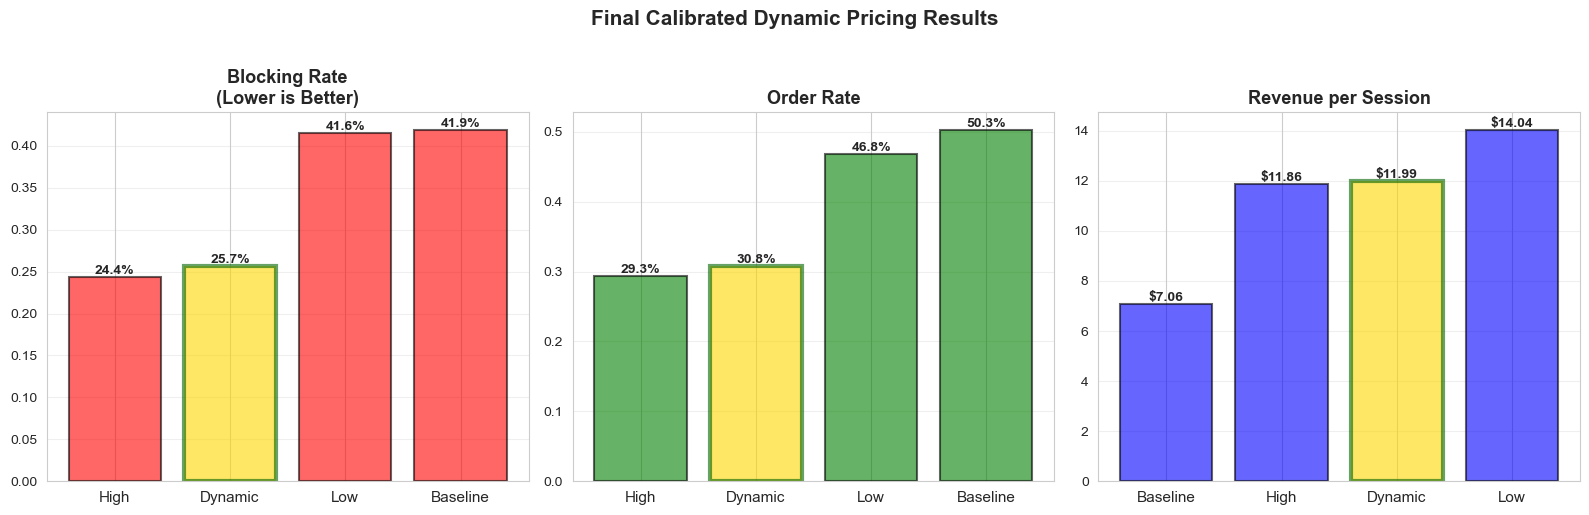

✓ Saved final_calibrated_results.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['blocking_rate', 'order_rate', 'revenue_per_session']
titles = ['Blocking Rate\n(Lower is Better)', 'Order Rate', 'Revenue per Session']
colors = ['red', 'green', 'blue']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx]
    means = results_df.groupby('strategy')[metric].mean().sort_values()
    
    bars = ax.bar(range(len(means)), means.values, color=color, alpha=0.6, edgecolor='black', linewidth=1.5)
    
    # Highlight dynamic strategy
    if 'dynamic' in means.index:
        dyn_idx = list(means.index).index('dynamic')
        bars[dyn_idx].set_color('gold')
        bars[dyn_idx].set_edgecolor('darkgreen')
        bars[dyn_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([s.capitalize() for s in means.index], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(means.values):
        label = f'${v:.2f}' if metric == 'revenue_per_session' else f'{v:.1%}'
        ax.text(i, v, label, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Final Calibrated Dynamic Pricing Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_calibrated_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved final_calibrated_results.png")

In [9]:
# Export results
results_df.to_csv('final_simulation_results.csv', index=False)
summary.to_csv('final_simulation_summary.csv')

print("✓ Exported:")
print("  - final_simulation_results.csv")
print("  - final_simulation_summary.csv")
print("  - final_calibrated_results.png")

✓ Exported:
  - final_simulation_results.csv
  - final_simulation_summary.csv
  - final_calibrated_results.png


## Conclusion

This simulation uses **real elasticity** from your data analysis:
- Pharma: -0.05 (nearly inelastic)
- Meal: -0.20 (modest sensitivity)
- Grocery: -0.30 (moderate sensitivity)

Plus the critical insight that **higher prices reduce blocking**.

If the dynamic model shows:
- ✅ Lower blocking rate
- ✅ Higher revenue per session
- ✅ Acceptable order rate (within 10-15% of baseline)

Then you have a **winning strategy** ready to present!